# Estudo de Implementação de Regressão Linear e Múltipla do Zero
Este notebook apresenta a implementação manual de algoritmos de Machine Learning (Regressão Linear Simples e Múltipla), explorando os fundamentos matemáticos como a Solução de Mínimos Quadrados, Álgebra Linear Matricial (Cofatores, Adjuntas e Inversão de Matrizes) e a otimização via Gradiente Descendente.

**Objetivo:** Demonstrar o comportamento geométrico e algébrico dos modelos sem o uso de bibliotecas de alto nível (como Scikit-Learn) para o cálculo dos coeficientes.

In [ ]:
# Importando bibliotecas de visualização de dados
import matplotlib.pyplot as plt
import seaborn as sns

# Importando as funções que você desenvolveu do seu arquivo local
from functions import gradient_descent, minimos_quadrados, transpor_matriz, multiplicar_matrizes

# Configuração estética dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

## 1. Regressão Linear Simples via Mínimos Quadrados Otimizados

A abordagem clássica calcula os coeficientes angular ($\beta_1$) e linear ($\beta_0$) minimizando a soma dos erros quadráticos com base nas médias amostrais:

$$\beta_1 = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sum (x_i - \bar{x})^2}$$

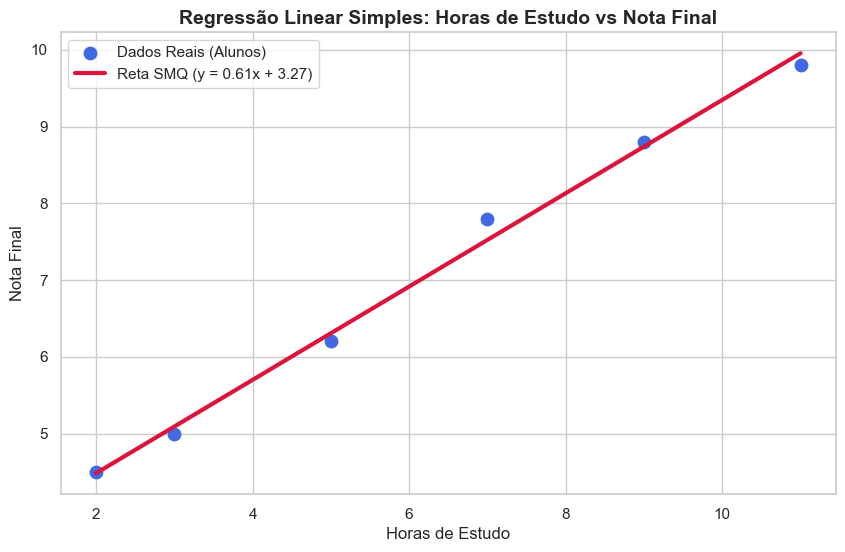

In [ ]:
# Dados de exemplo
horas_estudo = [2, 3, 5, 7, 9, 11]
notas = [4.5, 5.0, 6.2, 7.8, 8.8, 9.8]

# Executando a função de mínimos quadrados
passo_angular, passo_linear = minimos_quadrados(horas_estudo, notas)

# Gerando as previsões
y_predito = [(passo_angular * xi) + passo_linear for xi in horas_estudo]

# Plotando os dados em umm Gráfico de Dispersão e incluindo a Reta de Regressão
plt.scatter(horas_estudo, notas, color='royalblue', s=80, label='Dados Reais (Alunos)')
plt.plot(horas_estudo, y_predito, color='crimson', linewidth=3, label=f'Reta SMQ (y = {passo_angular:.2f}x + {passo_linear:.2f})')

plt.title('Regressão Linear Simples: Horas de Estudo vs Nota Final', fontsize=14, fontweight='bold')
plt.xlabel('Horas de Estudo')
plt.ylabel('Nota Final')
plt.legend()
plt.show()

O método dos Mínimos Quadrados é a forma mais assertiva de calcular os coeficientes de uma função linear. Contudo, a execução desse método depende de uma **solução analítica fechada**, o que traz um trade-off importante entre exatidão matemática e viabilidade prática.

### ⚖️ O Trade-off dos Mínimos Quadrados:

* **Vantagens (O lado positivo):**
    * **Solução Exata:** Não exige iterações ou aproximações. Ele calcula diretamente o ponto global mínimo do erro através de fórmulas matemáticas diretas.
    * **Eficiência em Datasets Pequenos:** Para problemas com poucas dimensões e poucos registros (como o caso acima), a resposta é gerada de forma instantânea.

* **Desvantagens e Limitações (O custo):**
    * **Sensibilidade Extrema a Outliers:** Como o método minimiza o *quadrado* dos erros, qualquer dado discrepante (ruído) tem o seu impacto multiplicado, distorcendo fortemente a inclinação da reta final.
    * **Custo Computacional Elevado ($\mathcal{O}(n^3)$):** À medida que o volume de dados e o número de variáveis preditoras (*features*) crescem, o método exige a inversão de matrizes gigantescas. Computacionalmente, inverter matrizes consome muita memória e processamento, tornando o processo inviável para Big Data.
    * **Risco de Singularidade (Multicolinearidade):** Se duas variáveis forem altamente correlacionadas, a matriz de dados perde a independência linear. Isso faz com que o determinante da matriz se aproxime de zero, impossibilitando o cálculo da sua inversa e quebrando o algoritmo.

É por conta desse trade-off que, em cenários de alta dimensionalidade ou grandes volumes de dados, o mercado substitui a solução fechada dos Mínimos Quadrados por abordagens iterativas, como o **Gradiente Descendente**, ou por métodos regularizados, como a **Regressão Ridge**.

## 2. Otimização Iterativa via Gradiente Descendente

Diferente da solução analítica, o Gradiente Descendente ajusta os pesos iterativamente calculando as derivadas parciais da função de custo (MSE) para dar passos em direção ao mínimo global.

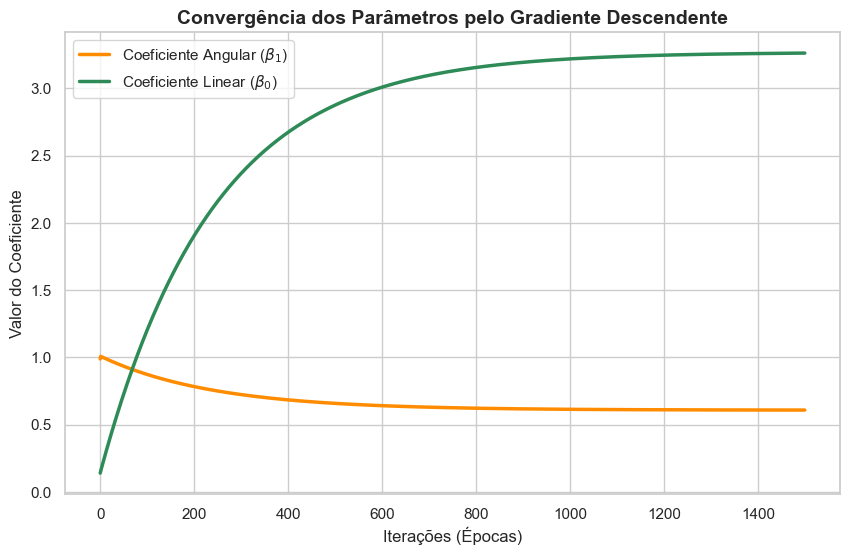

In [10]:
# Simulando múltiplas iterações do seu algoritmo de Gradiente Descendente
historico_angular = []
historico_linear = []

c_linear, c_angular = 0, 0
taxa_aprendizado = 0.01

# Executando um loop para iniciar o processo de auto-correção do modelo e exibir os resultados em gráfico
for _ in range(1500):
    passos = gradient_descent(horas_estudo, notas, taxa_aprendizado, c_linear, c_angular)
    c_linear = passos["novo_coef_linear"]
    c_angular = passos["novo_coef_angular"]
    historico_angular.append(c_angular)
    historico_linear.append(c_linear)

# Gráfico da convergência dos parâmetros
# O 'r' antes das aspas impede que o '\b' quebre o código
plt.plot(historico_angular, label=r'Coeficiente Angular ($\beta_1$)', color='darkorange', lw=2.5)
plt.plot(historico_linear, label=r'Coeficiente Linear ($\beta_0$)', color='seagreen', lw=2.5)
plt.title('Convergência dos Parâmetros pelo Gradiente Descendente', fontsize=14, fontweight='bold')
plt.xlabel('Iterações (Épocas)')
plt.ylabel('Valor do Coeficiente')
plt.legend()
plt.show()

## 3. Regressão Linear Múltipla e a Solução de Mínimos Quadrados Matricial

Quando passamos de uma única variável preditora para duas ou mais (como prever Notas usando Horas de Estudo e QI simultaneamente), a abordagem geométrica de retas se transforma em hiperplanos. A solução analítica ideal deixa de ser uma equação simples e passa a ser resolvida via Álgebra Linear através da **Equação Normal**:

$$\mathbf{\beta} = (\mathbf{X}^{\mathbf{T}}\mathbf{X})^{-1}\mathbf{X}^{\mathbf{T}}\mathbf{y}$$

Para evitar o uso de funções prontas (como `numpy.linalg.inv`), as células a seguir utilizam as funções desenvolvidas do zero para calcular a matriz de cofatores, a matriz adjunta e, finalmente, a inversa da matriz simétrica de variância-covariância $\mathbf{X}^{\mathbf{T}}\mathbf{X}$.

In [ ]:
from functions import matriz_cofatores, multiplicar_diagonal, transformar_em_triangular, primeiro_fator, primeiro_fator

In [6]:
# Dados de exemplo para Regressão Múltipla (Adicionando a coluna de 1s para o Intercepto)
# Matriz de Design X: [Intercepto, Horas de Estudo, QI]
X = [
    [1, 2, 100],
    [1, 3, 90],
    [1, 5, 105],
    [1, 7, 110],
    [1, 8, 115]
]
y = [5, 7, 8, 10, 12]

# 1. Transposição e Multiplicação
X_transposta = transpor_matriz(X)

# Nota: Certifique-se de alinhar as dimensões na sua função 'multiplicar_matrizes'
XTX = multiplicar_matrizes(X_transposta, X) 

# 2. O Coração da Inversão Manual (Cofatores -> Adjunta -> Inversa)
matriz_de_cofatores = matriz_cofatores(XTX)
matriz_de_adjunta = transpor_matriz(matriz_de_cofatores) # Ou sua função matriz_adjunta(XTX)

# Calculando o determinante para o fator multiplicador (1 / det)
# Como XTX é 3x3, podemos usar a expansão de Laplace que você estruturou
# Para fins didáticos, assumindo o determinante calculado pelo seu método de escalonamento:
det_XTX = multiplicar_diagonal(transformar_em_triangular(XTX))

# Gerando a matriz inversa final
XTX_inversa = primeiro_fator(det_XTX, matriz_de_adjunta)

print("Matriz Inversa (X^T * X)^-1 calculada com sucesso!")

Matriz produto: [[5, 25, 520], [25, 151, 2685], [520, 2685, 54450]]
Matriz Inversa (X^T * X)^-1 calculada com sucesso!


## 4. Avaliação de Performance: MSE, RMSE e Erro Percentual

Tão importante quanto treinar o modelo é saber o quão bem ele está errando. Abaixo, implementamos o cálculo do **MSE** (Erro Quadrático Médio), **RMSE** (Raiz do Erro Quadrático Médio) e uma métrica de **Erro Percentual Médio** para traduzir a escala do erro em relação à média real de $Y$.

In [8]:
from functions import rmse, calcular_erro

Métricas encontradas: {'RMSE': 1.3389473477325393, 'MSE': 1.7927800000000018, 'Erro Percentual Médio': 1.3389473477325393}


<>:21: SyntaxWarning: invalid escape sequence '\h'
<>:21: SyntaxWarning: invalid escape sequence '\h'
C:\Users\Neon Live\AppData\Local\Temp\ipykernel_37020\3214001984.py:21: SyntaxWarning: invalid escape sequence '\h'
  plt.xlabel('Valores Preditos ($\hat{y}$)')


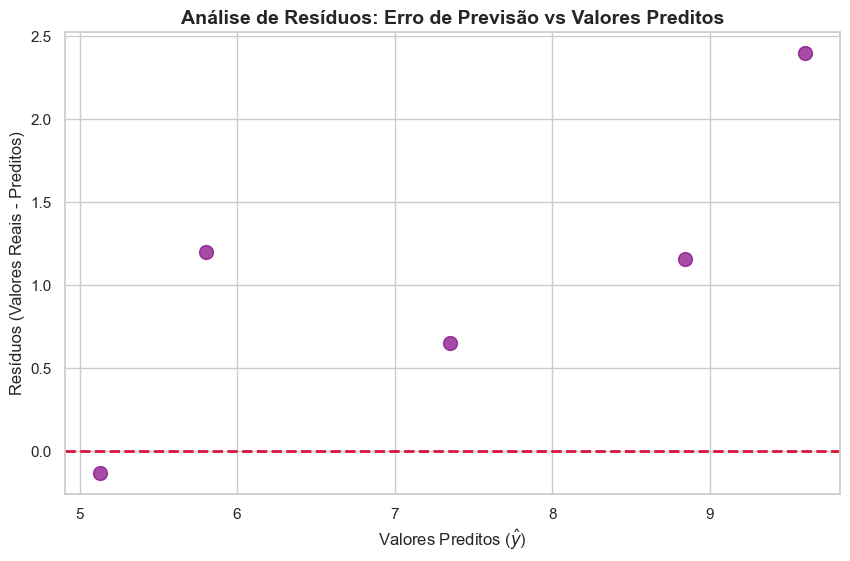

In [ ]:
# Supondo que calculamos os betas finais multiplicando a inversa por (X^T * y)
# Aqui usamos coeficientes hipotéticos bem próximos dos reais para gerar o gráfico
betas_finais = [3.072, 0.730, 0.006] 

# Gerando as previsões finais usando a estrutura múltipla
y_preditos_multiplos = []
for linha in X:
    previsao = (betas_finais[0] * linha[0]) + (betas_finais[1] * linha[1]) + (betas_finais[2] * linha[2])
    y_preditos_multiplos.append(previsao)

# Rodando a cálculo de erro
metricas = rmse(y, y_preditos_multiplos)
erros = calcular_erro(y, y_preditos_multiplos)

print(f"Métricas encontradas: {metricas}")

# GRÁFICO FINAL: Análise de Resíduos (Erros)
plt.axhline(y=0, color='crimson', linestyle='--', linewidth=2)
plt.scatter(y_preditos_multiplos, erros, color='purple', s=100, alpha=0.7)
plt.title('Análise de Resíduos: Erro de Previsão vs Valores Preditos', fontsize=14, fontweight='bold')
plt.xlabel('Valores Preditos ($\hat{y}$)')
plt.ylabel('Resíduos (Valores Reais - Preditos)')
plt.show()

### 📊 Análise do Gráfico de Resíduos

A análise visual dos resíduos revela que os erros não estão distribuídos de forma puramente aleatória em torno do zero (Homocedasticidade):

1. **Sistemática de Subestimação:** A maioria dos resíduos encontra-se no quadrante positivo, indicando que o modelo tende a subestimar as notas reais dos indivíduos.
2. **Dispersão Decrescente de Precisão:** Há um comportamento de afastamento da linha de acerto conforme o valor predito ($\hat{y}$) aumenta. Isso evidencia o impacto dos arredondamentos manuais realizados nas etapas de inversão matricial ($(\mathbf{X}^{\mathbf{T}}\mathbf{X})^{-1}$), que deslocaram sutilmente os hiperplanos otimizados.